## **Analyzing Spotify Listening Data!!**

**Establishing path and file name & Imports**

In [6]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
FILE_PATTERN = "Streaming_History_Audio_*.json"
DATA_FOLDER = Path("my_spotify_data") / "Spotify Extended Streaming History"

candidate_base_dirs = [Path.cwd(), Path.cwd().parent]
BASE_DIR = next((base for base in candidate_base_dirs if (base / DATA_FOLDER).exists()), None)

if BASE_DIR is None:
    raise FileNotFoundError(f"Could not find '{DATA_FOLDER}' from {candidate_base_dirs}")

PATH = BASE_DIR / DATA_FOLDER
files = sorted(PATH.glob(FILE_PATTERN))

print(f"Using data folder: {PATH}")
print(f"Found {len(files)} file(s).")

Using data folder: c:\Users\bhana\Downloads\music-insights-llm\my_spotify_data\Spotify Extended Streaming History
Found 6 file(s).


**creating dataframe for data**

In [16]:
if not files:
    raise FileNotFoundError(f"No JSON files found in: {PATH}")

df = pd.concat([pd.read_json(file) for file in files], ignore_index=True)

# Drop columns that aren't useful for analysis
drop_cols = [c for c in ["ip_addr", "offline_timestamp"] if c in df.columns] #dropping columns that aren't useful/privacy concerns
df = df.drop(columns=drop_cols)


In [17]:
print(df.shape)

(110626, 17)


In [18]:
df

,ts,platform,ms_played,conn_country,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,episode_name,episode_show_name,spotify_episode_uri,reason_start,reason_end,shuffle,skipped,offline,incognito_mode
0,2017-04-09T03:42:20Z,"iOS 10.2.1 (iPad5,3)",209208,US,Headlights (feat. Ilsey),Robin Schulz,Headlights (feat. Ilsey),spotify:track:06Hdbxh6NCy6TIhjdXTchB,None,None,None,clickrow,trackdone,False,False,False,False
1,2017-04-09T03:45:55Z,"iOS 10.2.1 (iPad5,3)",214840,US,Break Free,Ariana Grande,My Everything,spotify:track:12KUFSHFgT0XCoiSlvdQi4,None,None,None,trackdone,trackdone,False,False,False,False
2,2017-04-09T03:48:52Z,"iOS 10.2.1 (iPad5,3)",176561,US,Lean On,Major Lazer,Peace Is The Mission,spotify:track:5bcYCYn63zNOjBv3KPOLjd,None,None,None,trackdone,trackdone,False,False,False,False
3,2017-04-09T03:52:44Z,"iOS 10.2.1 (iPad5,3)",230613,US,Waiting For Love,Avicii,Stories,spotify:track:2P4OICZRVAQcYAV2JReRfj,None,None,None,trackdone,trackdone,False,False,False,False
4,2017-04-09T03:56:17Z,"iOS 10.2.1 (iPad5,3)",212862,US,Don't You Worry Child - Radio Edit,Swedish House Mafia,Don't You Worry Child,spotify:track:2V65y3PX4DkRhy1djlxd9p,None,None,None,trackdone,trackdone,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110621,2025-01-04T23:42:32Z,windows,137090,US,In My Head,Snow Strippers,April Mixtape 2,spotify:track:1MIKmAUOndg822y6CzuiHA,None,None,None,trackdone,trackdone,True,False,False,False
110622,2025-01-04T23:46:57Z,windows,268803,US,JRJRJR,Jane Remover,JRJRJR,spotify:track:1mW9XrT9XdnsDPuthSgusZ,None,None,None,trackdone,trackdone,True,False,False,False
110623,2025-01-04T23:50:00Z,windows,187095,US,Exitin,Cece Natalie,Miss Behaves,spotify:track:4KKqMfAZi5oz1kOWhLdmuL,None,None,None,trackdone,trackdone,True,False,False,False
110624,2025-01-04T23:53:45Z,windows,229106,US,wonder2,Perfume,Perfume～Complete Best～,spotify:track:3LqZhe0pkxDCIHH0eQabDv,None,None,None,trackdone,trackdone,True,False,False,False


**prior analysis**

looking into dataframe

In [19]:
print(df.dtypes)

ts                                   object
platform                             object
ms_played                             int64
conn_country                         object
master_metadata_track_name           object
master_metadata_album_artist_name    object
master_metadata_album_album_name     object
spotify_track_uri                    object
episode_name                         object
episode_show_name                    object
spotify_episode_uri                  object
reason_start                         object
reason_end                           object
shuffle                                bool
skipped                                bool
offline                                bool
incognito_mode                         bool
dtype: object


In [21]:
print(df["skipped"].value_counts())

skipped
False    94313
True     16313
Name: count, dtype: int64


In [22]:
print(df["offline"].value_counts())

offline
False    109679
True        947
Name: count, dtype: int64


In [23]:
#countries i've listened from
print(df["conn_country"].value_counts())

#US = United States
#ZZ = Unknown
#IN = India
#CA = Canada
#AE = United Arab Emirates

conn_country
US    93882
ZZ    15521
IN     1212
CA        8
AE        3
Name: count, dtype: int64


**PreProcessing**

fixing timezone first lul

In [24]:
df['ts'] = pd.to_datetime(df['ts'], format = "%Y-%m-%dT%H:%M:%SZ", utc = True)


#localiseing
import pytz
tz = pytz.timezone("America/New_York")
df['ts'] = df['ts'].dt.tz_convert(tz)


In [25]:
df.sort_values(by='ts', ascending=True, inplace=True)

In [26]:
df

,ts,platform,ms_played,conn_country,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,episode_name,episode_show_name,spotify_episode_uri,reason_start,reason_end,shuffle,skipped,offline,incognito_mode
0,2017-04-08 23:42:20-04:00,"iOS 10.2.1 (iPad5,3)",209208,US,Headlights (feat. Ilsey),Robin Schulz,Headlights (feat. Ilsey),spotify:track:06Hdbxh6NCy6TIhjdXTchB,None,None,None,clickrow,trackdone,False,False,False,False
1,2017-04-08 23:45:55-04:00,"iOS 10.2.1 (iPad5,3)",214840,US,Break Free,Ariana Grande,My Everything,spotify:track:12KUFSHFgT0XCoiSlvdQi4,None,None,None,trackdone,trackdone,False,False,False,False
2,2017-04-08 23:48:52-04:00,"iOS 10.2.1 (iPad5,3)",176561,US,Lean On,Major Lazer,Peace Is The Mission,spotify:track:5bcYCYn63zNOjBv3KPOLjd,None,None,None,trackdone,trackdone,False,False,False,False
3,2017-04-08 23:52:44-04:00,"iOS 10.2.1 (iPad5,3)",230613,US,Waiting For Love,Avicii,Stories,spotify:track:2P4OICZRVAQcYAV2JReRfj,None,None,None,trackdone,trackdone,False,False,False,False
4,2017-04-08 23:56:17-04:00,"iOS 10.2.1 (iPad5,3)",212862,US,Don't You Worry Child - Radio Edit,Swedish House Mafia,Don't You Worry Child,spotify:track:2V65y3PX4DkRhy1djlxd9p,None,None,None,trackdone,trackdone,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110621,2025-01-04 18:42:32-05:00,windows,137090,US,In My Head,Snow Strippers,April Mixtape 2,spotify:track:1MIKmAUOndg822y6CzuiHA,None,None,None,trackdone,trackdone,True,False,False,False
110622,2025-01-04 18:46:57-05:00,windows,268803,US,JRJRJR,Jane Remover,JRJRJR,spotify:track:1mW9XrT9XdnsDPuthSgusZ,None,None,None,trackdone,trackdone,True,False,False,False
110623,2025-01-04 18:50:00-05:00,windows,187095,US,Exitin,Cece Natalie,Miss Behaves,spotify:track:4KKqMfAZi5oz1kOWhLdmuL,None,None,None,trackdone,trackdone,True,False,False,False
110624,2025-01-04 18:53:45-05:00,windows,229106,US,wonder2,Perfume,Perfume～Complete Best～,spotify:track:3LqZhe0pkxDCIHH0eQabDv,None,None,None,trackdone,trackdone,True,False,False,False


In [27]:
df['year'] = df['ts'].dt.year #separating year from timestamp, separate column
df[['ts','year']]

,ts,year
0,2017-04-08 23:42:20-04:00,2017
1,2017-04-08 23:45:55-04:00,2017
2,2017-04-08 23:48:52-04:00,2017
3,2017-04-08 23:52:44-04:00,2017
4,2017-04-08 23:56:17-04:00,2017
...,...,...
110621,2025-01-04 18:42:32-05:00,2025
110622,2025-01-04 18:46:57-05:00,2025
110623,2025-01-04 18:50:00-05:00,2025
110624,2025-01-04 18:53:45-05:00,2025


**DATA VISUALIZATION**

In [28]:
country_counts = df["conn_country"].value_counts()

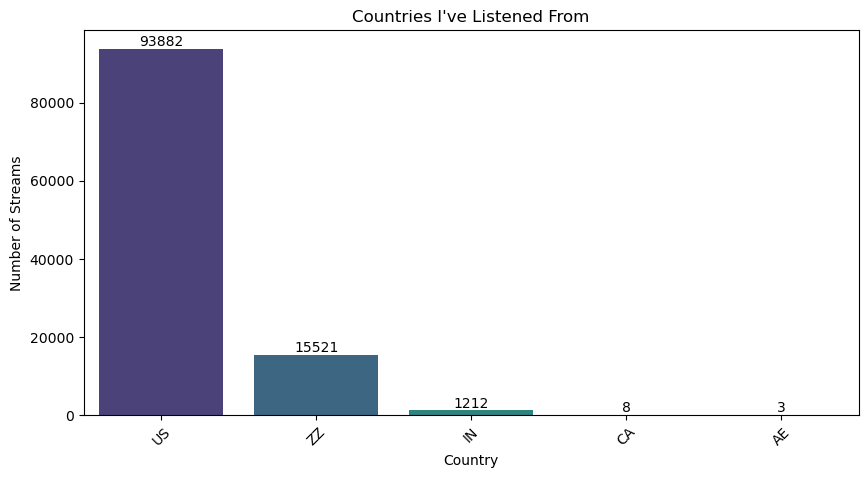

In [49]:
plt.figure(figsize=(10,5))
sns.barplot(x=country_counts.index, y=country_counts.values, palette="viridis", hue=country_counts.index)
plt.xlabel("Country")
plt.ylabel("Number of Streams")
plt.title("Countries I've Listened From")
plt.xticks(rotation=45)

for index, value in enumerate(country_counts.values):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.show()


**TOP 10 2024 Artists**

In [30]:
df[df['year']==2024].groupby('master_metadata_album_artist_name')['master_metadata_album_artist_name'].count().sort_values(ascending=False)

master_metadata_album_artist_name
Snow Strippers       1297
Charli xcx            983
MGNA Crrrta           828
Grimes                627
Caroline Polachek     597
                     ... 
Melanie Martinez        1
Merely                  1
$werve                  1
鬼堯                      1
funeral                 1
Name: master_metadata_album_artist_name, Length: 2042, dtype: int64

In [31]:
artists_2024 = df[df['year']==2024].groupby('master_metadata_album_artist_name')['master_metadata_album_artist_name'].count().sort_values(ascending=False)
top10_artists_2024 = artists_2024.head(10)

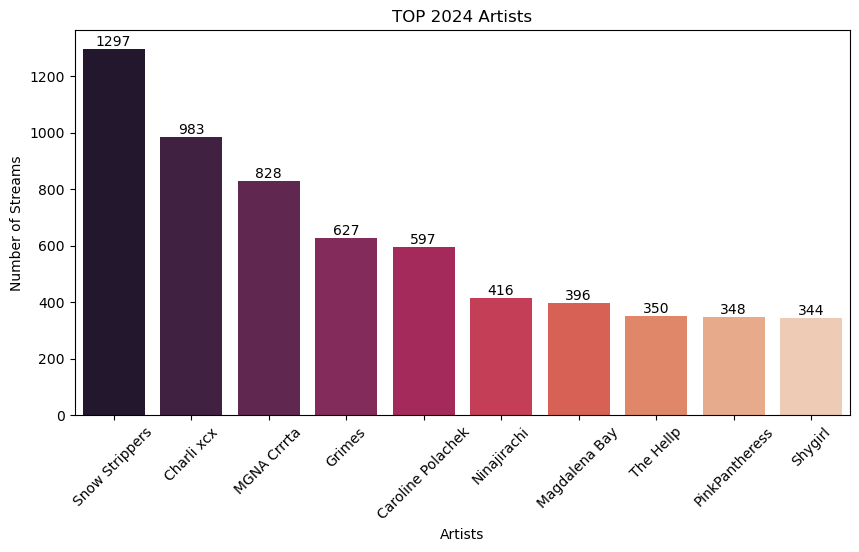

In [48]:
plt.figure(figsize=(10,5))
sns.barplot(x=top10_artists_2024.index, y=top10_artists_2024.values, palette="rocket", hue=top10_artists_2024.index)
plt.xlabel("Artists")
plt.ylabel("Number of Streams")
plt.title("TOP 2024 Artists")
plt.xticks(rotation=45)

for index, value in enumerate(top10_artists_2024.values):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.show()


**OFFLINE Column Investigation**

In [35]:
df[df['offline']==True].tail()

,ts,platform,ms_played,conn_country,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,episode_name,episode_show_name,spotify_episode_uri,reason_start,reason_end,shuffle,skipped,offline,incognito_mode,year
110249,2024-12-29 17:35:20-05:00,ios,166640,US,UP - KARINA Solo,aespa,SYNK : PARALLEL LINE - Special Digital Single,spotify:track:5sjnkOfTLCLNfkkchI2re2,None,None,None,trackdone,trackdone,True,False,True,False,2024
110250,2024-12-29 17:38:39-05:00,ios,198232,US,Fire in the belly,LE SSERAFIM,UNFORGIVEN,spotify:track:05RlBHEZg1RmL9DnPgv9Qq,None,None,None,trackdone,trackdone,True,False,True,False,2024
110251,2024-12-29 17:41:08-05:00,ios,148186,US,mute,Shygirl,Club Shy,spotify:track:3jxxGBDq5ePJE91R909Yae,None,None,None,trackdone,trackdone,True,False,True,False,2024
110252,2024-12-29 17:44:14-05:00,ios,186181,US,Your Teeth In My Neck,Kali Uchis,Isolation,spotify:track:54IbnYEdA3ymfxv07WgN3b,None,None,None,trackdone,trackdone,True,False,True,False,2024
110253,2024-12-29 17:45:46-05:00,ios,90181,US,Neverender - Kaytranada Remix,Justice,Neverender,spotify:track:1GFz4dKoSUt9aOBeLJFfJh,None,None,None,trackdone,endplay,True,True,True,False,2024


**Investigating Conn_Country Column**

Looking into unknown country "ZZ"

In [36]:
ermm = df[df['conn_country']=='ZZ']
ermm


,ts,platform,ms_played,conn_country,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,episode_name,episode_show_name,spotify_episode_uri,reason_start,reason_end,shuffle,skipped,offline,incognito_mode,year
66,2017-05-25 16:43:14-04:00,Partner spotify web_player,176586,ZZ,HUMBLE.,Kendrick Lamar,DAMN.,spotify:track:7KXjTSCq5nL1LoYtL7XAwS,None,None,None,clickrow,unknown,False,False,False,False,2017
67,2017-05-25 16:48:52-04:00,Partner spotify web_player,287944,ZZ,I'm the One,DJ Khaled,I'm the One,spotify:track:72Q0FQQo32KJloivv5xge2,None,None,None,clickrow,unknown,False,False,False,False,2017
68,2017-05-25 16:49:35-04:00,Partner spotify web_player,2947,ZZ,HUMBLE.,Kendrick Lamar,DAMN.,spotify:track:7KXjTSCq5nL1LoYtL7XAwS,None,None,None,clickrow,trackdone,False,False,False,False,2017
69,2017-05-25 16:52:43-04:00,Partner spotify web_player,185180,ZZ,DNA.,Kendrick Lamar,DAMN.,spotify:track:6HZILIRieu8S0iqY8kIKhj,None,None,None,clickrow,unknown,False,False,False,False,2017
70,2017-05-25 16:55:56-04:00,Partner spotify web_player,26460,ZZ,LOVE. FEAT. ZACARI.,Kendrick Lamar,DAMN.,spotify:track:6PGoSes0D9eUDeeAafB2As,None,None,None,unknown,trackdone,False,False,False,False,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31656,2020-08-17 22:01:48-04:00,web_player windows 10;chrome 84.0.4147.125;des...,67441,ZZ,Hello Kitty,Jazmin Bean,Worldwide Torture,spotify:track:5GCwCzJkdefEhYU6mLyRu1,None,None,None,remote,endplay,False,False,False,False,2020
31657,2020-08-17 22:02:55-04:00,web_player windows 10;chrome 84.0.4147.125;des...,42622,ZZ,Signs,Snoop Dogg,R&G (Rhythm & Gangsta): The Masterpiece,spotify:track:4HSAJpNocVNJbwbQvtCMdO,None,None,None,clickrow,endplay,False,False,False,False,2020
31658,2020-08-17 22:02:55-04:00,web_player windows 10;chrome 84.0.4147.125;des...,42622,ZZ,Signs,Snoop Dogg,R&G (Rhythm & Gangsta): The Masterpiece,spotify:track:4HSAJpNocVNJbwbQvtCMdO,None,None,None,clickrow,endplay,False,False,False,False,2020
31659,2020-08-17 22:08:33-04:00,web_player windows 10;chrome 84.0.4147.125;des...,285431,ZZ,Where's Your Head At,Basement Jaxx,Rooty,spotify:track:6cOyq898FB1fYOewPOwjyS,None,None,None,playbtn,trackdone,False,False,False,False,2020


Listening History in Canada

In [37]:
yerm = df[df['conn_country']=='CA']
yerm

,ts,platform,ms_played,conn_country,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,episode_name,episode_show_name,spotify_episode_uri,reason_start,reason_end,shuffle,skipped,offline,incognito_mode,year
63810,2023-02-10 18:03:03-05:00,windows,197415,CA,Turning Wheel,SPELLLING,The Turning Wheel,spotify:track:0mBpuZq2VrGiE2SCKRykV8,None,None,None,trackdone,endplay,True,True,False,False,2023
63811,2023-02-10 18:05:28-05:00,windows,144098,CA,SO HOT - THEBLACKLABEL REMIX BLACKPINK ARENA T...,BLACKPINK,"BLACKPINK ARENA TOUR 2018 ""SPECIAL FINAL IN KY...",spotify:track:1fMXWEkJpIH483OrKn1zFV,None,None,None,clickrow,trackdone,True,False,False,False,2023
63812,2023-02-10 18:05:32-05:00,windows,3658,CA,SOLO,JENNIE,SOLO,spotify:track:2wVDWtLKXunswWecARNILj,None,None,None,trackdone,endplay,True,True,False,False,2023
63813,2023-02-10 18:08:47-05:00,windows,193858,CA,Villain,PIXY,REBORN,spotify:track:5Doeu3aSa5tBHayCx0EbHa,None,None,None,clickrow,trackdone,True,False,False,False,2023
65720,2023-03-19 16:36:16-04:00,windows,57353,CA,Look,Red Velvet,Perfect Velvet - The 2nd Album,spotify:track:48Nd8rdc0WVG4rHTd76Mh6,None,None,None,trackdone,unexpected-exit,True,False,False,False,2023
76600,2023-11-18 17:37:47-05:00,windows,196757,CA,"Sex, Drugs, Etc.",Beach Weather,Chit Chat,spotify:track:7DbdUf8aHSYoliSjO6LZv6,None,None,None,trackdone,trackdone,True,False,False,False,2023
76601,2023-11-18 17:43:27-05:00,windows,333815,CA,Enter Sandman,Rina Sawayama,Enter Sandman,spotify:track:18sXLZIxb7nYy3g0Wnx8bA,None,None,None,trackdone,trackdone,True,False,False,False,2023
76629,2023-11-18 20:25:55-05:00,windows,1389,CA,She Wolf,Shakira,She Wolf (Expanded Edition),spotify:track:4cS2HQ6jK80vqdY9ofpztx,None,None,None,trackdone,unexpected-exit-while-paused,True,False,False,False,2023


**TOP 2024 Artists Extended?**

In [38]:
#artists_2024 = df[df['year']==2024].groupby('master_metadata_album_artist_name')['master_metadata_album_artist_name'].count().sort_values(ascending=False)
top20_artists_2024 = artists_2024.head(25)

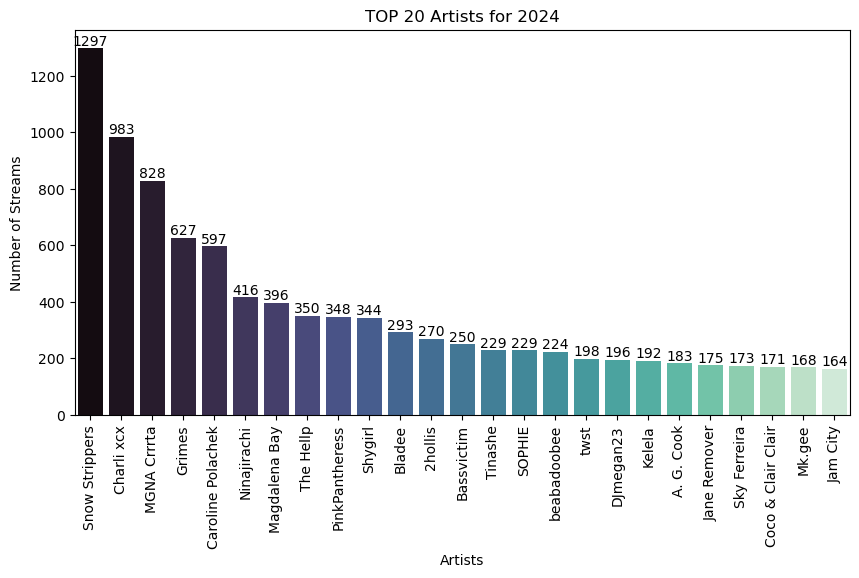

In [47]:
plt.figure(figsize=(10,5))
sns.barplot(x=top20_artists_2024.index, y=top20_artists_2024.values, palette="mako", hue = top20_artists_2024.index)
plt.xlabel("Artists")
plt.ylabel("Number of Streams")
plt.title("TOP 20 Artists for 2024")
plt.xticks(rotation=90)

for index, value in enumerate(top20_artists_2024.values):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.show()


**TOP SONGS OF 2024?!?!**

In [41]:
top_songs_2024 = df[df['year']==2024].groupby('master_metadata_track_name')['master_metadata_track_name'].count().sort_values(ascending=False)
top10_songs_2024 = top_songs_2024.head(10)

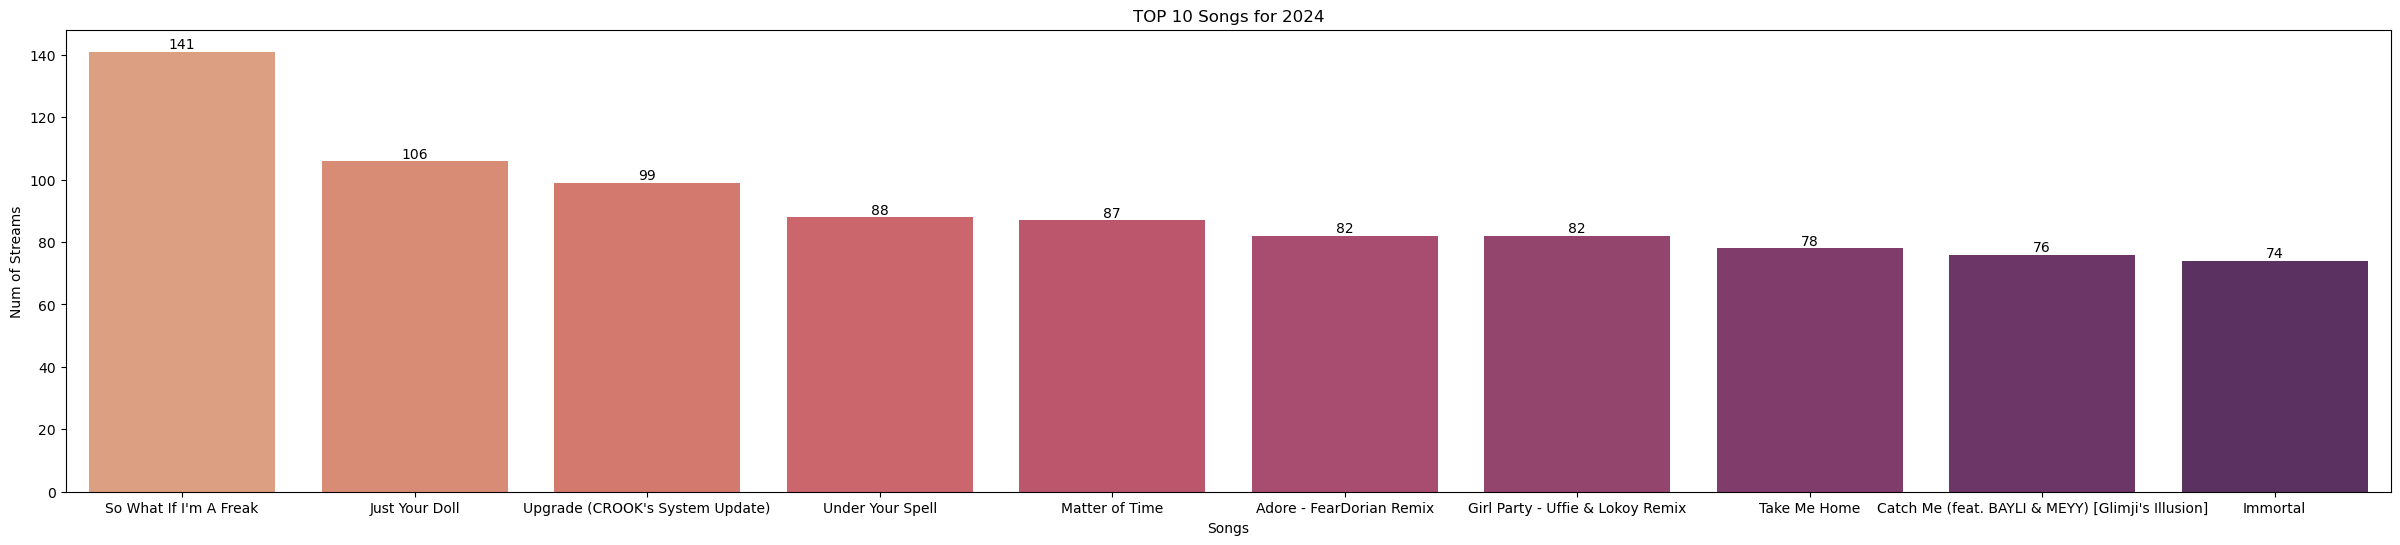

In [45]:
plt.figure(figsize=(30,6))
sns.barplot(x=top10_songs_2024.index, y=top10_songs_2024.values, hue=top10_songs_2024.index, palette="flare")
plt.xlabel("Songs")
plt.ylabel("Num of Streams")
plt.title("TOP 10 Songs for 2024")
plt.xticks(rotation=0)

for index, value in enumerate(top10_songs_2024.values):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.show()


**TOP SONGS OF 2025??**

up still jan 4 which is when data collection for this dataset ends

In [43]:
top_songs_2025 = df[df['year']==2025].groupby('master_metadata_track_name')['master_metadata_track_name'].count().sort_values(ascending=False)
t10_25 = top_songs_2025.head(10)

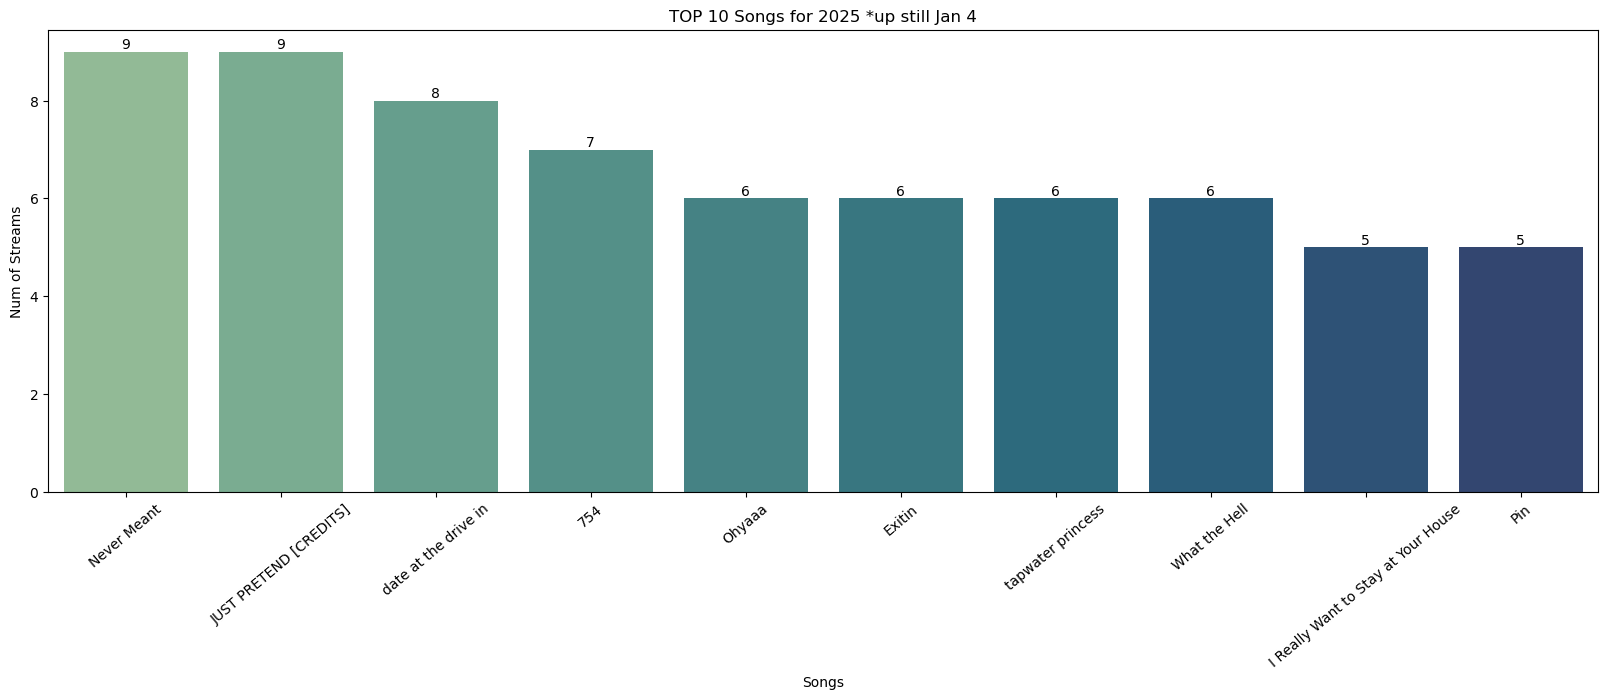

In [46]:
plt.figure(figsize=(20,6))
sns.barplot(x=t10_25.index, y=t10_25.values, palette="crest", hue=t10_25.index)
plt.xlabel("Songs")
plt.ylabel("Num of Streams")
plt.title("TOP 10 Songs for 2025 *up still Jan 4")
plt.xticks(rotation=40)

for index, value in enumerate(t10_25.values):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.show()
